# Notebook 7: Protected Land Gate

Adds a hard buildability gate for protected and off-limits land. No GDAL — uses `requests` and `geopandas` polygon overlay.

| Source | Coverage |
|---|---|
| Esri USA Federal Lands (Living Atlas) | NPS, USFWS, DoD, Forest Service |
| Census TIGER AIANNH | Tribal / American Indian lands (sovereign) |

**Gate:** cells where > 25% of area overlaps protected land receive `protected_score = 0.0` and are excluded from the composite regardless of slider settings.

In [1]:
import shutil
import warnings
from pathlib import Path

import geopandas as gpd
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import requests

warnings.filterwarnings("ignore")

RAW       = Path("../data/raw")
PROCESSED = Path("../data/processed")
CRS_PROJ  = "EPSG:32610"
DARK_BG   = "#1a1a2e"
WHITE     = "white"

plt.rcParams.update({
    "text.color": WHITE, "axes.labelcolor": WHITE,
    "xtick.color": WHITE, "ytick.color": WHITE, "font.size": 16,
})
print("Imports OK")

/home/simonhans/anaconda3/lib/python3.7/site-packages/geopandas/_compat.py:115: UserWarning: The Shapely GEOS version (3.11.4-CAPI-1.17.4) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  shapely_geos_version, geos_capi_version_string


Imports OK


## 1. Download Federal Protected Lands

**Esri USA Federal Lands** (Living Atlas public service) covers all federally managed land by agency. We filter to four agencies whose land is effectively off-limits to commercial data center development:

| Agency | Covers |
|---|---|
| National Park Service | National Parks, Monuments, Seashores, Recreation Areas |
| Fish and Wildlife Service | National Wildlife Refuges, Wilderness Areas |
| Department of Defense | Military installations (bases, ranges, restricted zones) |
| Forest Service | National Forests (complex NEPA permitting; effectively unavailable for large-pad commercial development) |

BLM is deliberately excluded — BLM land can be leased for commercial purposes and should not be blanket-gated.

Results cached locally; re-runs skip the download.

In [2]:
FED_LANDS_URL = "https://services.arcgis.com/P3ePLMYs2RVChkJx/arcgis/rest/services/USA_Federal_Lands/FeatureServer/0/query"
WA_BBOX       = "-124.733,45.543,-116.916,49.002"   # west,south,east,north
CACHE_FED     = RAW / "wa_federal_lands.geojson"

AGENCIES = (
    "'National Park Service',"
    "'Fish and Wildlife Service',"
    "'Department of Defense',"
    "'Forest Service'"
)
WHERE = f"Agency IN ({AGENCIES})"

def fetch_federal_lands(cache_path):
    if cache_path.exists():
        print(f"  Using cached {cache_path.name}")
        return gpd.read_file(cache_path)
    features = []
    offset   = 0
    while True:
        r = requests.get(FED_LANDS_URL, params={
            "where":              WHERE,
            "geometry":           WA_BBOX,
            "geometryType":       "esriGeometryEnvelope",
            "spatialRel":         "esriSpatialRelIntersects",
            "inSR":               "4326",
            "outFields":          "Agency,unit_name",
            "returnGeometry":     "true",
            "f":                  "geojson",
            "resultRecordCount":  1000,
            "resultOffset":       offset,
        }, timeout=120)
        r.raise_for_status()
        data  = r.json()
        batch = data.get("features", [])
        features.extend(batch)
        print(f"    {len(features)} features...")
        if len(batch) < 1000:
            break
        offset += 1000
    gdf = gpd.GeoDataFrame.from_features(features, crs="EPSG:4326")
    gdf = gdf[gdf.geometry.notna() & gdf.geometry.is_valid]
    gdf.to_file(cache_path, driver="GeoJSON")
    return gdf

print("Fetching Esri USA Federal Lands (NPS + USFWS + DoD + FS)...")
fed_lands = fetch_federal_lands(CACHE_FED)

print(f"\nTotal features: {len(fed_lands)}")
print(fed_lands["Agency"].value_counts().to_string())

Fetching Esri USA Federal Lands (NPS + USFWS + DoD + FS)...
    1000 features...
    2000 features...
    3000 features...
    4000 features...
    5000 features...
    5172 features...

Total features: 5139
Fish and Wildlife Service    4105
Forest Service                684
National Park Service         304
Department of Defense          46


## 2. Supplement with Census TIGER Tribal Boundaries

PAD-US may not capture all American Indian land areas. The Census TIGER AIANNH layer (federally recognized tribal areas) is a reliable supplement for tribal sovereignty boundaries.

In [3]:
CACHE_TRIBAL = RAW / "wa_tribal_tiger.geojson"
TIGER_URL    = "https://tigerweb.geo.census.gov/arcgis/rest/services/TIGERweb/AIANNHA/MapServer/3/query"

if CACHE_TRIBAL.exists():
    print(f"Using cached {CACHE_TRIBAL.name}")
    tribal = gpd.read_file(CACHE_TRIBAL)
else:
    r = requests.get(TIGER_URL, params={
        "geometry":     WA_BBOX,
        "geometryType": "esriGeometryEnvelope",
        "spatialRel":   "esriSpatialRelIntersects",
        "inSR":         "4326",
        "outFields":    "NAME,AIANNHNS",
        "returnGeometry": "true",
        "f":            "geojson",
    }, timeout=60)
    r.raise_for_status()
    tribal = gpd.GeoDataFrame.from_features(r.json()["features"], crs="EPSG:4326")
    tribal = tribal[tribal.geometry.notna() & tribal.geometry.is_valid]
    tribal.to_file(CACHE_TRIBAL, driver="GeoJSON")

print(f"TIGER tribal areas in WA bbox: {len(tribal)}")
if len(tribal) > 0:
    print(tribal["NAME"].tolist())

TIGER tribal areas in WA bbox: 24
['Hoh Off-Reservation Trust Land', 'Chehalis Off-Reservation Trust Land', 'Squaxin Island Off-Reservation Trust Land', 'Umatilla Off-Reservation Trust Land', 'Celilo Village', 'Snoqualmie Off-Reservation Trust Land', 'Muckleshoot Off-Reservation Trust Land', 'Puyallup Off-Reservation Trust Land', 'Colville Off-Reservation Trust Land', 'Shoalwater Bay Off-Reservation Trust Land', 'Spokane Off-Reservation Trust Land', 'Yakama Nation Off-Reservation Trust Land', 'Warm Springs Off-Reservation Trust Land', 'Nooksack Off-Reservation Trust Land', 'Kalispel Off-Reservation Trust Land', 'Port Gamble Off-Reservation Trust Land', 'Swinomish Off-Reservation Trust Land', 'Upper Skagit Off-Reservation Trust Land', 'Cowlitz Off-Reservation Trust Land', "Jamestown S'Klallam Off-Reservation Trust Land", 'Stillaguamish Off-Reservation Trust Land', 'Tulalip Off-Reservation Trust Land', 'Lower Elwha Off-Reservation Trust Land', 'Skokomish Off-Reservation Trust Land']


## 3. Merge and Dissolve All Protected Areas

In [4]:
fed_lands["source"] = "Esri Federal Lands"
tribal["source"]    = "TIGER AIANNH"

import pandas as pd
all_prot = gpd.GeoDataFrame(
    pd.concat([fed_lands[["geometry", "source"]],
               tribal[["geometry", "source"]]], ignore_index=True),
    crs="EPSG:4326"
)

all_prot_proj = all_prot.to_crs(CRS_PROJ)
prot_dissolved = all_prot_proj.dissolve().reset_index(drop=True)

wa = gpd.read_file(RAW / "wa_state.geojson").to_crs(CRS_PROJ)
wa_area_km2   = wa.geometry.area.sum() / 1e6
prot_area_km2 = prot_dissolved.geometry.area.sum() / 1e6
print(f"WA state area:        {wa_area_km2:,.0f} km2")
print(f"Protected area total: {prot_area_km2:,.0f} km2  ({prot_area_km2/wa_area_km2:.1%} of state)")

WA state area:        184,776 km2
Protected area total: 13,429 km2  (7.3% of state)


## 4. Compute Protected Fraction per Grid Cell

`geopandas.overlay(how='intersection')` clips protected polygons to each grid cell. The ratio of clipped area to cell area gives `protected_frac`.

In [5]:
dc_gdf = gpd.read_file(RAW / "datacenters.geojson").to_crs(CRS_PROJ)
grid   = gpd.read_file("../static/grid_scores.geojson")
print(f"Grid: {len(grid)} cells")
print(f"Columns: {[c for c in grid.columns if c != 'geometry']}")

grid_proj = grid.to_crs(CRS_PROJ).copy()
grid_proj["cell_id"]   = grid_proj.index
grid_proj["cell_area"] = grid_proj.geometry.area

print("Computing intersections (may take a minute)...")
isect = gpd.overlay(
    grid_proj[["cell_id", "cell_area", "geometry"]],
    prot_dissolved[["geometry"]],
    how="intersection",
    keep_geom_type=False
)
isect["prot_area"] = isect.geometry.area

prot_by_cell = isect.groupby("cell_id")["prot_area"].sum()
cell_areas   = grid_proj.set_index("cell_id")["cell_area"]

grid["protected_frac"] = (
    prot_by_cell.reindex(cell_areas.index, fill_value=0) / cell_areas
).clip(0, 1).values

print(f"protected_frac range:  {grid.protected_frac.min():.3f} - {grid.protected_frac.max():.3f}")
print(f"Median protected_frac: {grid.protected_frac.median():.3f}")
print(f"Cells with >25% protected: {(grid.protected_frac > 0.25).sum()}")

Grid: 974 cells
Columns: ['cell_id', 'tx_score', 'water_score', 'ej_score', 'seismic_score', 'flood_score', 'contamination_score', 'waterway_score', 'geothermal_score', 'flatness_score']
Computing intersections (may take a minute)...
protected_frac range:  0.000 - 1.000
Median protected_frac: 0.000
Cells with >25% protected: 82


## 5. Apply Hard Gate

In [6]:
GATE = 0.25

gated     = grid["protected_frac"] > GATE
n_gated   = gated.sum()
n_clear   = (~gated).sum()

grid["protected_score"] = 1.0
grid.loc[gated, "protected_score"] = 0.0

print(f"Gate:           protected_frac > {GATE:.0%}")
print(f"Gated:          {n_gated} cells  ({n_gated  / len(grid):.1%})")
print(f"Clear:          {n_clear} cells  ({n_clear  / len(grid):.1%})")

Gate:           protected_frac > 25%
Gated:          82 cells  (8.4%)
Clear:          892 cells  (91.6%)


## 6. Map

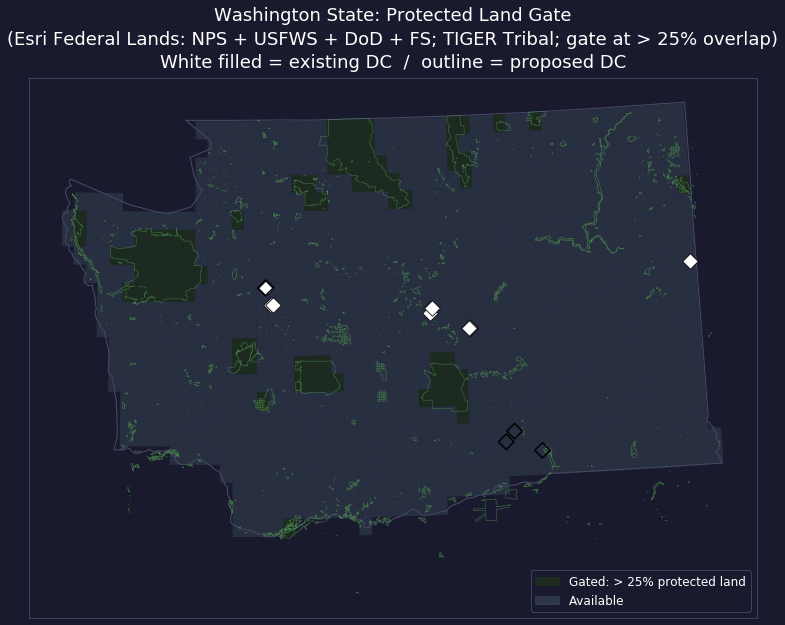

Saved to data/processed/protected_land.png and static/img/protected_land.png


In [7]:
grid_plot  = grid.to_crs(CRS_PROJ)
wa_plot    = wa
gated_plot = grid_plot[gated]
clear_plot = grid_plot[~gated]

fig, ax = plt.subplots(1, 1, figsize=(12, 10), facecolor=DARK_BG)
ax.set_facecolor(DARK_BG)
wa_plot.boundary.plot(ax=ax, color="#4a4a6a", linewidth=1.0, zorder=1)

if len(gated_plot) > 0:
    gated_plot.plot(ax=ax, color="#1e2e1e", alpha=0.85, zorder=2)

clear_plot.plot(ax=ax, color="#3a4a5a", alpha=0.45, zorder=2)

prot_dissolved.boundary.plot(ax=ax, color="#4a8a4a", linewidth=0.6, alpha=0.7, zorder=3)

dc_all   = gpd.read_file(RAW / "datacenters.geojson").to_crs(CRS_PROJ)
rep_pts  = dc_all[dc_all["source"] == "reported"]
prop_pts = dc_all[dc_all["source"] == "proposed"]
ax.scatter(rep_pts.geometry.x,  rep_pts.geometry.y,
           c=WHITE, s=120, marker="D", zorder=5, edgecolors="black", linewidths=0.8)
ax.scatter(prop_pts.geometry.x, prop_pts.geometry.y,
           facecolors="none", s=120, marker="D", zorder=5, edgecolors="black", linewidths=1.5)

gated_patch = mpatches.Patch(color="#1e2e1e", alpha=0.9,
                              label=f"Gated: > {GATE:.0%} protected land")
clear_patch = mpatches.Patch(color="#3a4a5a", alpha=0.6, label="Available")
leg = ax.legend(handles=[gated_patch, clear_patch], loc="lower right",
                facecolor="#1a1a2e", edgecolor="#4a4a6a", fontsize=12)
for text in leg.get_texts():
    text.set_color(WHITE)

ax.set_title(
    "Washington State: Protected Land Gate\n"
    "(Esri Federal Lands: NPS + USFWS + DoD + FS; TIGER Tribal; gate at > 25% overlap)\n"
    "White filled = existing DC  /  outline = proposed DC",
    color=WHITE, fontsize=18, pad=10, linespacing=1.4
)
ax.set_xlabel(""); ax.set_ylabel("")
ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
for spine in ax.spines.values():
    spine.set_edgecolor("#4a4a6a")

plt.tight_layout()
out_proc = PROCESSED / "protected_land.png"
out_web  = Path("../static/img/protected_land.png")
plt.savefig(out_proc, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
shutil.copy(out_proc, out_web)
plt.show()
print(f"Saved to {out_proc} and {out_web}")

## 7. Key Findings

In [8]:
grid["centroid"] = grid.geometry.centroid

def nearest_cell(pt):
    dists = grid.centroid.apply(lambda c: pt.distance(c))
    return grid.loc[dists.idxmin()]

print("=== Proposed Sites ===")
dc_gdf_wgs = gpd.read_file(RAW / "datacenters.geojson")
for _, row in dc_gdf_wgs[dc_gdf_wgs["source"] == "proposed"].iterrows():
    n = nearest_cell(row.geometry)
    status = "GATED (protected)" if n.protected_frac > GATE else "CLEAR"
    print(f'  {row["name"]}:\n'
          f'    protected_frac={n.protected_frac:.3f}  [{status}]\n')

print("=== Existing Clusters ===")
seen = set()
for _, row in dc_gdf_wgs[dc_gdf_wgs["source"] == "reported"].iterrows():
    n = nearest_cell(row.geometry)
    key = round(n.protected_frac, 3)
    if key in seen:
        continue
    seen.add(key)
    status = "GATED (protected)" if n.protected_frac > GATE else "CLEAR"
    print(f'  {row["name"]}:\n'
          f'    protected_frac={n.protected_frac:.3f}  [{status}]\n')

=== Proposed Sites ===
  Digital Realty (proposed):
    protected_frac=0.000  [CLEAR]

  Amazon Wallula Gap (proposed):
    protected_frac=0.019  [CLEAR]

  Atlas Agro Richland DC1 (proposed):
    protected_frac=0.000  [CLEAR]

  Trammell Crow Lewis Clark (proposed):
    protected_frac=0.000  [CLEAR]

=== Existing Clusters ===
  Microsoft Quincy Campus:
    protected_frac=0.000  [CLEAR]



## 8. Export Updated grid_scores.geojson

In [9]:
grid_out = grid.drop(columns=["centroid", "protected_frac"], errors="ignore")
grid_out.to_file("../static/grid_scores.geojson", driver="GeoJSON")
print("Saved ../static/grid_scores.geojson")
print(f"Columns: {list(grid_out.columns)}")

Saved ../static/grid_scores.geojson
Columns: ['cell_id', 'tx_score', 'water_score', 'ej_score', 'seismic_score', 'flood_score', 'contamination_score', 'waterway_score', 'geothermal_score', 'flatness_score', 'geometry', 'protected_score']
